--- CSI_HUMAN (มีคน) ---
  จำนวน samples     : 255
  ระยะเวลาเก็บข้อมูล : 29.9 วินาที
  RSSI mean/std      : -55.30 / 0.59 dBm
  CSI amplitude mean : 9.44
  CSI amplitude std  : 7.32

--- CSI_NO_HUMAN (ไม่มีคน) ---
  จำนวน samples     : 401
  ระยะเวลาเก็บข้อมูล : 29.9 วินาที
  RSSI mean/std      : -65.35 / 13.09 dBm
  CSI amplitude mean : 9.71
  CSI amplitude std  : 6.67

บันทึกกราฟที่ csi_summary_4.png เรียบร้อย


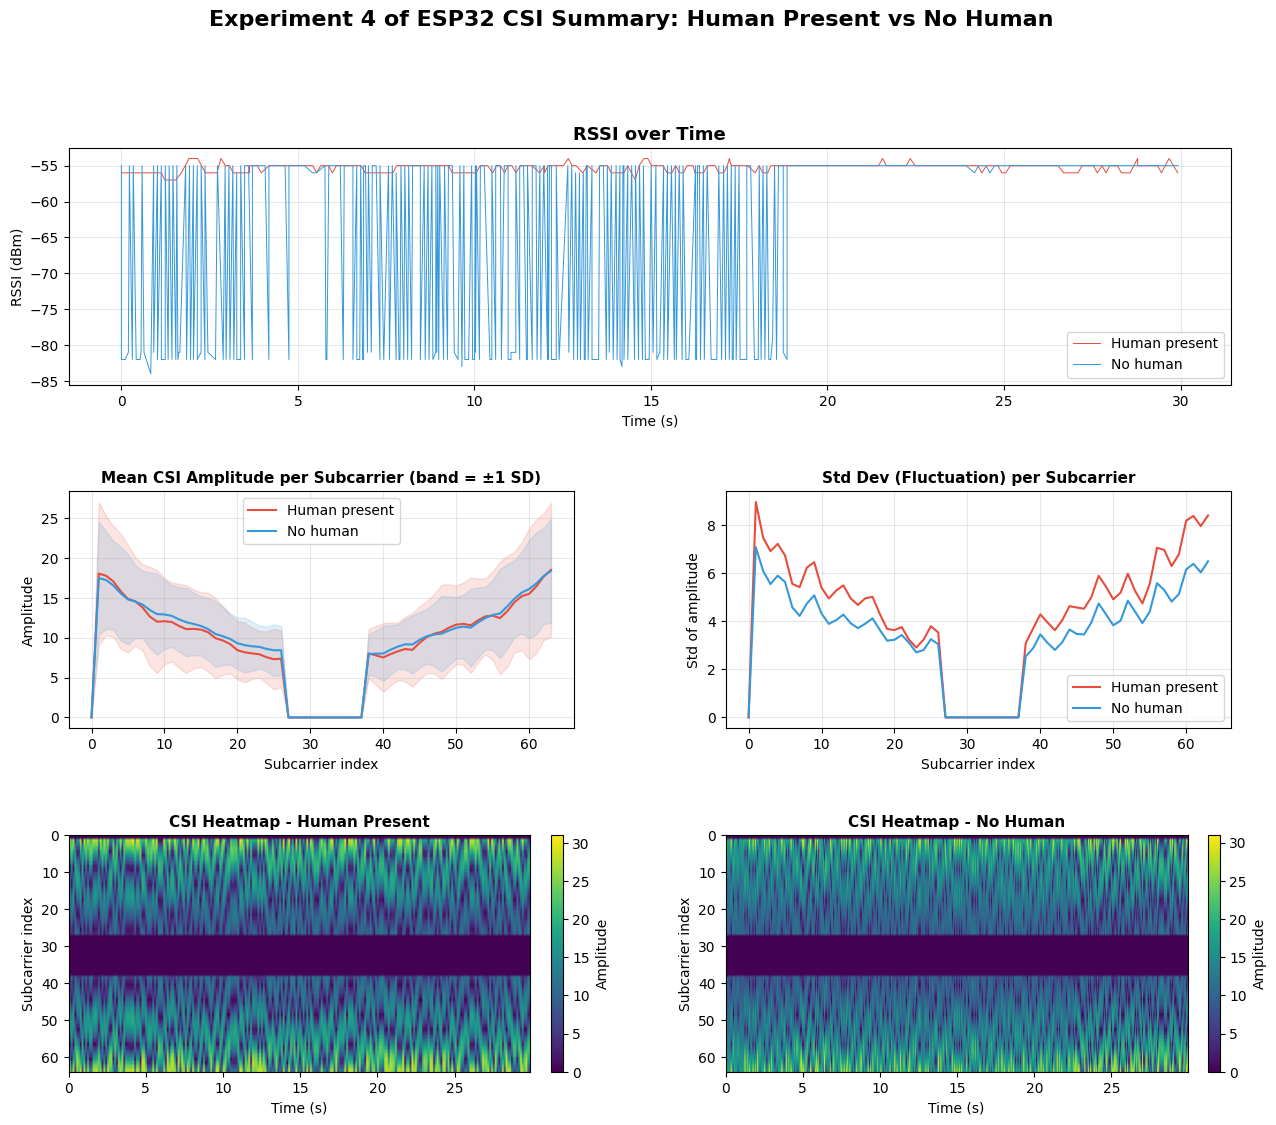

In [6]:
"""
CSI Data Summary & Visualization
=================================
เปรียบเทียบข้อมูล CSI (Channel State Information) ที่เก็บจาก ESP32-S3 / ESP32
ระหว่างช่วง "มีคน" (CSI_HUMAN.csv) กับ "ไม่มีคน" (CSI_ON_HUMAN.csv)

Output: csi_summary.png (กราฟรวม 6 แผง)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---------- 1) โหลดข้อมูล ----------
exp_no = "4";
HUMAN_PATH = f"./experiment/csi_exp{exp_no}_presence.csv"
NOHUMAN_PATH = f"./experiment/csi_exp{exp_no}_absent.csv"

df_human = pd.read_csv(HUMAN_PATH)
df_nohuman = pd.read_csv(NOHUMAN_PATH)

sub_cols = [c for c in df_human.columns if c.startswith("Sub_")]

# ทำเวลาให้เริ่มที่ 0 วินาที (relative time)
for df in (df_human, df_nohuman):
    df["t"] = df["Timestamp"] - df["Timestamp"].iloc[0]

# ---------- 2) สรุปสถิติพื้นฐาน ----------
def summarize(df, name):
    csi_vals = df[sub_cols].values
    print(f"--- {name} ---")
    print(f"  จำนวน samples     : {len(df)}")
    print(f"  ระยะเวลาเก็บข้อมูล : {df['t'].iloc[-1]:.1f} วินาที")
    print(f"  RSSI mean/std      : {df['RSSI'].mean():.2f} / {df['RSSI'].std():.2f} dBm")
    print(f"  CSI amplitude mean : {csi_vals.mean():.2f}")
    print(f"  CSI amplitude std  : {csi_vals.std():.2f}")
    print()

summarize(df_human, "CSI_HUMAN (มีคน)")
summarize(df_nohuman, "CSI_NO_HUMAN (ไม่มีคน)")

# ---------- 3) วาดกราฟ ----------
fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

COLOR_HUMAN = "#e74c3c"
COLOR_NOHUMAN = "#3498db"

# (a) RSSI over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_human["t"], df_human["RSSI"], color=COLOR_HUMAN, lw=0.7, label="Human present")
ax1.plot(df_nohuman["t"], df_nohuman["RSSI"], color=COLOR_NOHUMAN, lw=0.7, label="No human")
ax1.set_title("RSSI over Time", fontsize=13, fontweight="bold")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("RSSI (dBm)")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# (b) Mean CSI amplitude per subcarrier (+- std band)
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(sub_cols))
mean_h, std_h = df_human[sub_cols].mean().values, df_human[sub_cols].std().values
mean_n, std_n = df_nohuman[sub_cols].mean().values, df_nohuman[sub_cols].std().values
ax2.plot(x, mean_h, color=COLOR_HUMAN, label="Human present")
ax2.fill_between(x, mean_h - std_h, mean_h + std_h, color=COLOR_HUMAN, alpha=0.15)
ax2.plot(x, mean_n, color=COLOR_NOHUMAN, label="No human")
ax2.fill_between(x, mean_n - std_n, mean_n + std_n, color=COLOR_NOHUMAN, alpha=0.15)
ax2.set_title("Mean CSI Amplitude per Subcarrier (band = ±1 SD)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Subcarrier index")
ax2.set_ylabel("Amplitude")
ax2.legend()
ax2.grid(alpha=0.3)

# (c) Std (variability) per subcarrier - comparison bar
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(x, std_h, color=COLOR_HUMAN, label="Human present")
ax3.plot(x, std_n, color=COLOR_NOHUMAN, label="No human")
ax3.set_title("Std Dev (Fluctuation) per Subcarrier", fontsize=11, fontweight="bold")
ax3.set_xlabel("Subcarrier index")
ax3.set_ylabel("Std of amplitude")
ax3.legend()
ax3.grid(alpha=0.3)

# (d) Heatmap - HUMAN
ax4 = fig.add_subplot(gs[2, 0])
im1 = ax4.imshow(df_human[sub_cols].values.T, aspect="auto", cmap="viridis",
                  extent=[0, df_human["t"].iloc[-1], len(sub_cols), 0])
ax4.set_title("CSI Heatmap - Human Present", fontsize=11, fontweight="bold")
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Subcarrier index")
fig.colorbar(im1, ax=ax4, label="Amplitude", fraction=0.046, pad=0.04)

# (e) Heatmap - NO HUMAN
ax5 = fig.add_subplot(gs[2, 1])
im2 = ax5.imshow(df_nohuman[sub_cols].values.T, aspect="auto", cmap="viridis",
                  extent=[0, df_nohuman["t"].iloc[-1], len(sub_cols), 0])
ax5.set_title("CSI Heatmap - No Human", fontsize=11, fontweight="bold")
ax5.set_xlabel("Time (s)")
ax5.set_ylabel("Subcarrier index")
fig.colorbar(im2, ax=ax5, label="Amplitude", fraction=0.046, pad=0.04)

fig.suptitle(f"Experiment {exp_no} of ESP32 CSI Summary: Human Present vs No Human",
             fontsize=16, fontweight="bold", y=0.995)

plt.savefig(f"./csi_compare_{exp_no}.png", dpi=150, bbox_inches="tight")
print(f"บันทึกกราฟที่ csi_summary_{exp_no}.png เรียบร้อย")